In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("dt_prepared.csv") 

X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11, stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

svm_train_preview = pd.concat([X_train, y_train], axis=1)
svm_test_preview = pd.concat([X_test, y_test], axis=1)

svm_train_preview.head(100).to_csv("svm_train_sample.csv", index=False)
svm_test_preview.head(100).to_csv("svm_test_sample.csv", index=False)

print("\nTrain Sample:")
display(svm_train_preview.head())

print("\nTest Sample:")
display(svm_test_preview.head())


Training Set Shape: (56000, 33)
Testing Set Shape: (14000, 33)

Train Sample:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms,Target
46981,0,0,0,1,23.0,37,27.0,2,1,121,...,0,0,1,1,0,44,2,3653,0,5
53951,1,0,0,0,33.0,14,23.0,0,1,103,...,1,0,1,2,0,73,2,3159,0,0
17370,1,1,1,1,8.0,24,16.0,2,0,91,...,0,0,1,2,1,41,3,2558,1,8
35377,0,0,1,1,11.0,13,15.0,2,1,106,...,1,1,0,2,1,55,2,3972,1,8
4467,1,1,1,0,9.0,10,14.0,1,1,72,...,1,1,0,1,1,27,2,1914,1,4



Test Sample:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms,Target
4350,1,1,0,0,19.0,39,25.0,2,0,120,...,0,0,1,2,0,68,2,3294,1,5
14665,0,0,1,0,15.0,53,30.0,2,0,126,...,0,1,1,2,1,77,2,3898,1,6
57348,0,1,1,0,16.0,35,31.0,0,1,119,...,1,1,0,2,0,72,0,4057,1,1
65011,1,1,0,0,12.0,21,17.0,0,1,106,...,1,0,1,2,1,63,3,2810,0,8
62793,0,0,1,1,27.0,44,26.0,0,0,140,...,0,0,0,2,1,73,1,3548,1,6


Reduced Training Shape: (1000, 33)
Training SVM | Kernel: linear, C: 0.1
Training SVM | Kernel: linear, C: 1
Training SVM | Kernel: linear, C: 10
Training SVM | Kernel: rbf, C: 0.1
Training SVM | Kernel: rbf, C: 1
Training SVM | Kernel: rbf, C: 10
Training SVM | Kernel: poly, C: 0.1
Training SVM | Kernel: poly, C: 1
Training SVM | Kernel: poly, C: 10


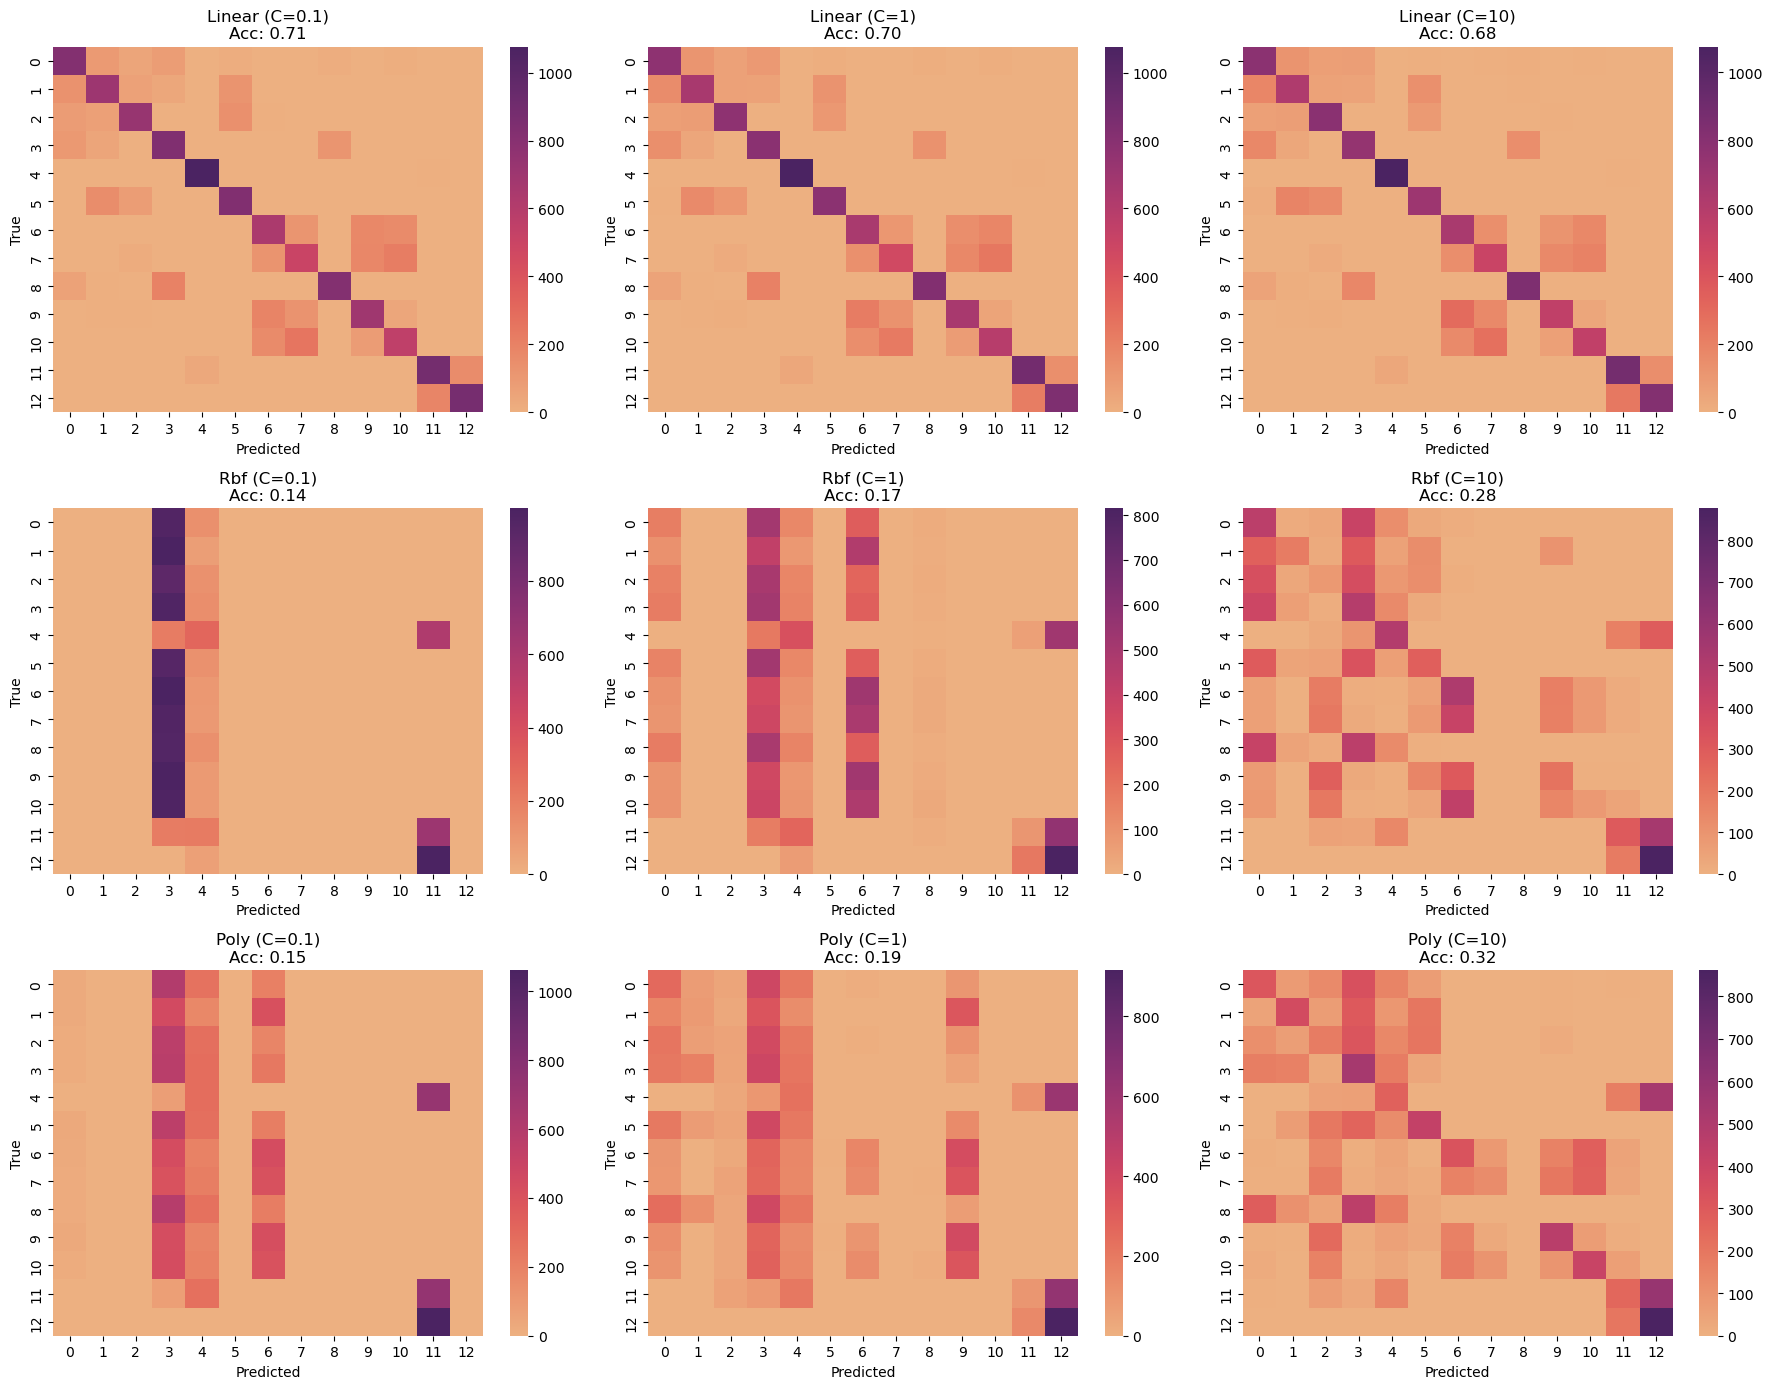


SVM Accuracies (FAST Downsampled Training):
Kernel: linear   | C:  0.1 | Accuracy: 0.7126
Kernel: linear   | C:    1 | Accuracy: 0.6974
Kernel: linear   | C:   10 | Accuracy: 0.6796
Kernel: rbf      | C:  0.1 | Accuracy: 0.1377
Kernel: rbf      | C:    1 | Accuracy: 0.1742
Kernel: rbf      | C:   10 | Accuracy: 0.2844
Kernel: poly     | C:  0.1 | Accuracy: 0.1469
Kernel: poly     | C:    1 | Accuracy: 0.1856
Kernel: poly     | C:   10 | Accuracy: 0.3226


In [6]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, train_size=1000, random_state=11)

for train_idx, _ in sss.split(X_train, y_train):
    X_train_small = X_train.iloc[train_idx]
    y_train_small = y_train.iloc[train_idx]

print(f"Reduced Training Shape: {X_train_small.shape}")

kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

plot_idx = 0
svm_results_small = []

for kernel in kernels:
    for C in C_values:
        print(f"Training SVM | Kernel: {kernel}, C: {C}")
        
        model = SVC(kernel=kernel, C=C, random_state=42)
        model.fit(X_train_small, y_train_small)
        
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        svm_results_small.append({
            'Kernel': kernel,
            'C': C,
            'Accuracy': acc
        })
        
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=False, fmt='d', cmap='flare', ax=axes[plot_idx])
        axes[plot_idx].set_title(f"{kernel.capitalize()} (C={C})\nAcc: {acc:.2f}")
        axes[plot_idx].set_xlabel("Predicted")
        axes[plot_idx].set_ylabel("True")
        
        plot_idx += 1

plt.tight_layout()
plt.show()

print("\nSVM Accuracies (FAST Downsampled Training):")
for result in svm_results_small:
    print(f"Kernel: {result['Kernel']:8} | C: {result['C']:>4} | Accuracy: {result['Accuracy']:.4f}")


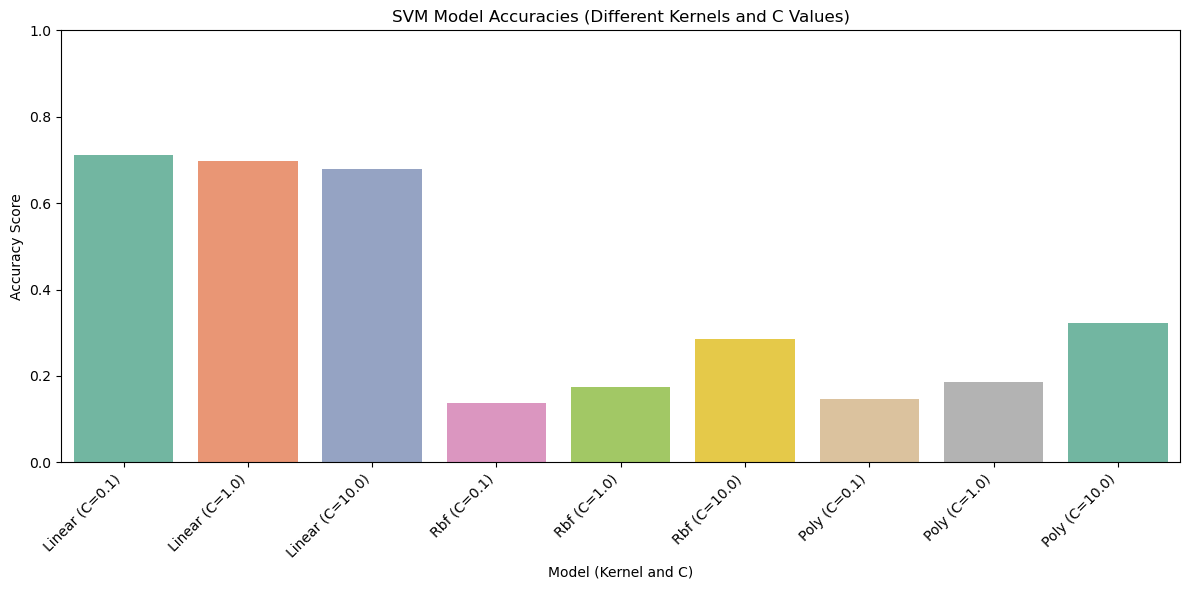

In [7]:
results_df = pd.DataFrame(svm_results_small)

results_df['Model'] = results_df['Kernel'].str.capitalize() + " (C=" + results_df['C'].astype(str) + ")"

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='Set2')

plt.title("SVM Model Accuracies (Different Kernels and C Values)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)  
plt.xlabel("Model (Kernel and C)")
plt.ylabel("Accuracy Score")
plt.tight_layout()
plt.show()


Training SVM | Kernel: linear, C: 0.1
Training SVM | Kernel: linear, C: 1
Training SVM | Kernel: linear, C: 10
Training SVM | Kernel: rbf, C: 0.1
Training SVM | Kernel: rbf, C: 1
Training SVM | Kernel: rbf, C: 10
Training SVM | Kernel: poly, C: 0.1
Training SVM | Kernel: poly, C: 1
Training SVM | Kernel: poly, C: 10


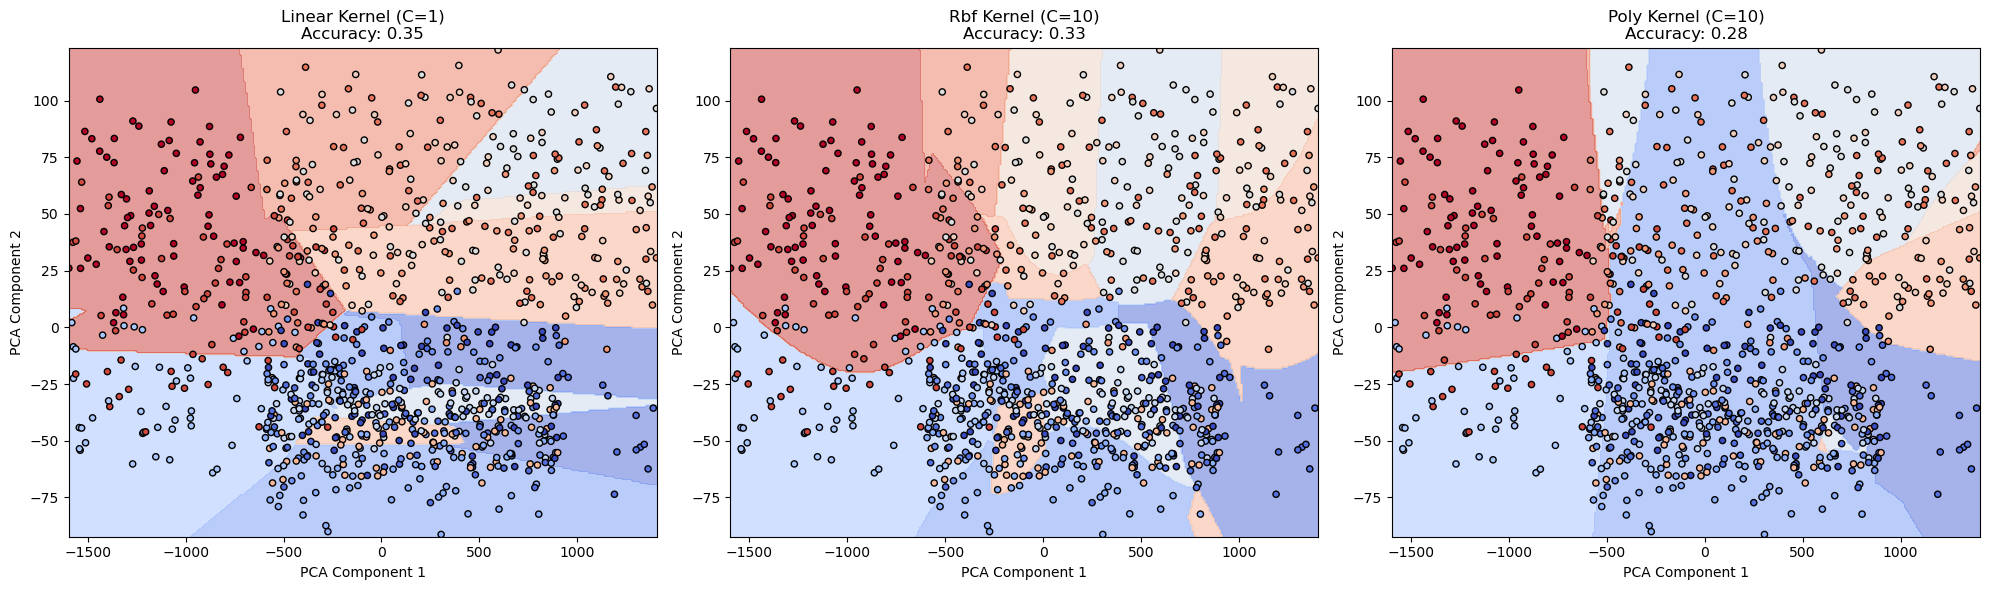

In [9]:
import numpy as np
from sklearn.decomposition import PCA
sss = StratifiedShuffleSplit(n_splits=1, train_size=1000, random_state=11)
for train_idx, _ in sss.split(X_train, y_train):
    X_train_small = X_train.iloc[train_idx]
    y_train_small = y_train.iloc[train_idx]

pca = PCA(n_components=2)
X_train_small_pca = pca.fit_transform(X_train_small)
X_test_pca = pca.transform(X_test)



kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]

svm_models = []

for kernel in kernels:
    for C in C_values:
        print(f"Training SVM | Kernel: {kernel}, C: {C}")
        
        model = SVC(kernel=kernel, C=C, random_state=42)
        model.fit(X_train_small_pca, y_train_small)
        
        y_pred = model.predict(X_test_pca)
        acc = accuracy_score(y_test, y_pred)
        
        svm_models.append({
            'Kernel': kernel,
            'C': C,
            'Accuracy': acc,
            'Model': model
        })

best_models_by_kernel = []
for kernel in kernels:
    models_of_kernel = [m for m in svm_models if m['Kernel'] == kernel]
    top_model = sorted(models_of_kernel, key=lambda x: x['Accuracy'], reverse=True)[0]  # Pick best one
    best_models_by_kernel.append(top_model)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
xx, yy = np.meshgrid(
    np.linspace(X_train_small_pca[:, 0].min()-1, X_train_small_pca[:, 0].max()+1, 300),
    np.linspace(X_train_small_pca[:, 1].min()-1, X_train_small_pca[:, 1].max()+1, 300)
)

for idx, content in enumerate(best_models_by_kernel):
    model = content['Model']
    kernel = content['Kernel']
    C = content['C']
    acc = content['Accuracy']
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
    axes[idx].scatter(X_train_small_pca[:, 0], X_train_small_pca[:, 1], c=y_train_small, edgecolor='k', s=20, cmap='coolwarm')
    axes[idx].set_title(f"{kernel.capitalize()} Kernel (C={C})\nAccuracy: {acc:.2f}")
    axes[idx].set_xlabel("PCA Component 1")
    axes[idx].set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()


# SVM Kernel Comparison and Discussion

## Overview

We experimented with Support Vector Machines (SVMs) using three different kernels (`linear`, `rbf`, and `poly`) and three different C values (`0.1`, `1`, and `10`).  
The models were trained on a stratified, downsampled training set to ensure faster computation while maintaining class balance.

## Results Summary

| Kernel | C Value | Accuracy |
|:------:|:-------:|:--------:|
| Linear | 0.1     | 0.71     |
| Linear | 1       | 0.70     |
| Linear | 10      | 0.68     |
| RBF    | 0.1     | 0.14     |
| RBF    | 1       | 0.17     |
| RBF    | 10      | 0.28     |
| Poly   | 0.1     | 0.15     |
| Poly   | 1       | 0.19     |
| Poly   | 10      | 0.32     |

---

## Discussion

- **Linear Kernel**:  
  The linear kernel performed the best overall. Across all C values, the linear SVM achieved accuracies between 68% and 71%.  
  Linear SVMs are often effective when the data is approximately linearly separable, which seems true for our dataset even after downsampling.
  
- **RBF Kernel**:  
  The RBF (Radial Basis Function) kernel performed the worst, with very low accuracies (ranging from 14% to 28%).  
  This suggests that the RBF kernel might be overfitting on a small training set or that the data does not have a complex nonlinear structure that RBF would benefit from.

- **Polynomial Kernel**:  
  The polynomial kernel performed slightly better than RBF but still worse than linear, reaching up to 32% accuracy at best.  
  Polynomial kernels are sensitive to the degree and C value. With a larger training set and further tuning, performance might improve, but for now, it underperforms compared to linear.

---

## Conclusion

- **Best Kernel**:  
  **Linear** kernel with **C=0.1** gave the highest accuracy at **~71%**.

- **Best Model Characteristics**:
  - Simpler, faster to compute.
  - Less prone to overfitting with a small sample size.
  - Performs consistently across multiple C values.

- **Recommendation**:  
  For this diabetes prediction task (based on PCA-transformed, downsampled features), **linear SVM** with a moderate to low C value is the most suitable choice.

---

## Visuals Used

- **Confusion Matrix Heatmaps** for all 9 models (Linear, RBF, and Poly kernels at 3 different C values).
- **Accuracy Comparison Bar Plot** displaying model performance side-by-side.

---


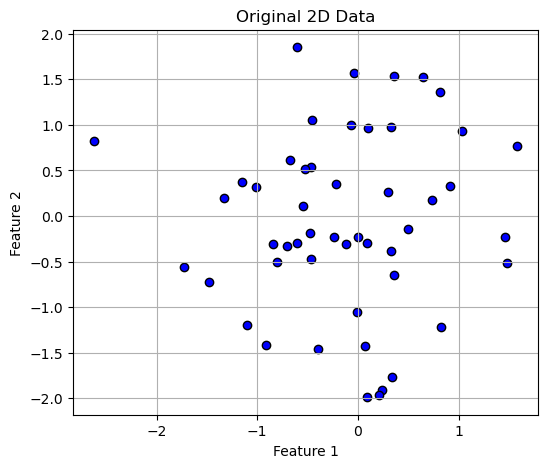

Original Shape: (50, 2)
After Polynomial Mapping Shape: (50, 5)


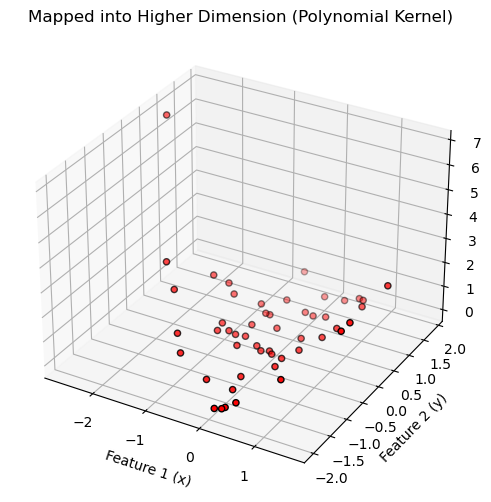

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)
X = np.random.randn(50, 2)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k')
plt.title("Original 2D Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Original Shape: {X.shape}")
print(f"After Polynomial Mapping Shape: {X_poly.shape}") 

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_poly[:, 0], X_poly[:, 1], X_poly[:, 2], c='red', edgecolor='k')
ax.set_title("Mapped into Higher Dimension (Polynomial Kernel)")
ax.set_xlabel("Feature 1 (x)")
ax.set_ylabel("Feature 2 (y)")
ax.set_zlabel("Feature 1^2 (x^2)")
plt.show()
